# Question 2: Vision in the Real World – Indian Currency Classification

## Part A: Theoretical Foundations

### 2A.1 Spatial Dimension Calculation

The formula for the output spatial dimension of a convolutional layer is:

$O = \lfloor\frac{I - K + 2P}{S}\rfloor + 1$

**(a)** We have a 3×128×128 input image going through a Conv2D with 32 filters, 3×3 kernel, stride 2, padding 1.

Here I = 128, K = 3, P = 1, S = 2.

$O = \lfloor\frac{128 - 3 + 2(1)}{2}\rfloor + 1 = \lfloor\frac{127}{2}\rfloor + 1 = 63 + 1 = 64$

The same formula applies to both height and width since they're both 128. The layer uses 32 filters, so the number of output channels is 32.

Output volume: 32 × 64 × 64

**(b)** Now we take the 32×64×64 output and pass it through a second Conv2D with 64 filters, 3×3 kernel, stride 1, padding 1.

I = 64, K = 3, S = 1, P = 1.

$O = \lfloor\frac{64 - 3 + 2(1)}{1}\rfloor + 1 = \lfloor\frac{63}{1}\rfloor + 1 = 63 + 1 = 64$

With stride 1 and padding 1, the spatial dimensions stay the same. This layer has 64 filters.

Resulting volume: 64 × 64 × 64

---

### 2A.2 Receptive Field

**(a)** The receptive field of a neuron is the region in the original input image that can influence the value of that neuron. Each neuron in a convolutional layer only "sees" a small local patch of its input. But as we stack more layers, deeper neurons effectively "see" larger portions of the input because each layer builds on top of the previous one's local view.

Having a large receptive field is important because the network needs to capture global context — things like the overall shape of an object, or the relationship between distant parts of an image. If every neuron can only see a tiny patch, the network would struggle to learn features that depend on the bigger picture.

**(b)** For two stacked 3×3 convolutions (both stride 1, no pooling):

- After the first 3×3 conv: each neuron sees a 3×3 patch of the input → receptive field = 3×3
- After the second 3×3 conv: each neuron sees a 3×3 patch of the first layer's output. But each of those values already represents a 3×3 patch of the original input. So the effective receptive field is 5×5.

A single 5×5 convolution also gives a 5×5 receptive field.

Parameter comparison (ignoring biases, for C input and C output channels):
- Two stacked 3×3 convs: $2 \times (C \times C \times 3 \times 3) = 18C^2$ parameters
- One 5×5 conv: $C \times C \times 5 \times 5 = 25C^2$ parameters

So two stacked 3×3 convolutions use fewer parameters ($18C^2$ vs $25C^2$) while achieving the same receptive field. This is exactly why architectures like VGG prefer stacking small kernels — you get the same receptive field with fewer parameters and more non-linearity (since there's a ReLU between the two layers).

---

### 2A.3 Parameter Efficiency

**(a)** Standard Conv2D mapping 32 input channels to 64 output channels with a 3×3 kernel:

weights: each of the 64 filters has a 3×3 kernel applied across all 32 input channels : 64 * 32 * 3 * 3 = 18432 weights
Biases: one per output channel : 64 biases
Total: 18432 + 64 = 18496 parameters

**(b)** Depthwise Separable Convolution for the same mapping (32 → 64 channels):

Step 1 — Depthwise conv (3×3 kernel, applied independently to each of the 32 input channels):
Weights: 32 * 3 × 3 = 288
Biases: 32
Subtotal: 320

Step 2 — Pointwise conv (1×1 kernel, mapping 32 channels to 64):
Weights: 64 * 32 * 1 * 1 = 2048
Biases: 64
Subtotal: 2112

Total: 320 + 2112 = 2432 parameters

**(c)** Compression ratio: 18496 / 2432 ≈ 7.6

So the depthwise separable version uses roughly 7.6× fewer parameters. MobileNet style architectures rely heavily on this factorization because it dramatically cuts down computation and model size while keeping accuracy reasonably close to standard convolutions. This makes them practical for mobile and embedded devices where memory and compute power are limited. The key idea is that spatial filtering (depthwise) and channel mixing (pointwise) can be separated without losing too much representational power.

---

### 2A.4 BatchNorm vs. LayerNorm – Choosing the Right Normalization

**(a)** For a CNN with feature maps of shape (B, C, H, W), BatchNorm computes the mean and variance over the B, H, W axes — that is, for each channel independently it aggregates statistics across all samples in the batch and across all spatial positions.

in other words, for channel $c$, the mean is computed as:
$\mu_c = \frac{1}{B \times H \times W} \sum_{b,h,w} x_{b,c,h,w}$

So there's one mean and one variance per channel and they're computed by averaging over everything except the channel dimension.

**(b)** with a batch size of 2 BatchNorm is estimating the mean and variance of each channel from just 2 samples. That's way too few to get a reliable estimate of the true distribution — the statistics will be extremely noisy and will fluctuate wildly from one mini-batch to the next. This makes training unstable because the normalization becomes unreliable.

An alternative that handles small batches well is Group Normalization (GroupNorm). GroupNorm divides channels into groups and normalizes within each group for each sample independently, so it doesn't depend on batch size at all. Instance Normalization is another option.

**(c)** in NLP Transformers sequences within a batch typically have different lengths. Even after padding, the padded positions don't carry meaningful information. If we try to compute BatchNorm-style statistics across the batch dimension for each position in the sequence, we'd be mixing statistics from real tokens and padding tokens across different samples, which doesn't make sense.

also the "same position" in different sequences doesn't really correspond to the same semantic role (unlike the same spatial location in images which roughly corresponds to the same region). So batch-level statistics across the sequence dimension aren't meaningful.

LayerNorm avoids all of this by normalizing each token's feature vector independently — it computes the mean and variance across the feature dimension for each individual token. this way it doesn't matter how long the sequence is or how other samples in the batch look. That's why it became the standard choice for Transformers.

---

## Part B: Practical Implementation

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
import copy

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Choose device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ===== DATASET INFORMATION =====
# Indian Currency Notes Dataset
# Google Drive Link for testing only: https://drive.google.com/drive/folders/1BtzirBf2e3UMuJWf-z5zjcsQMrHPC89-?usp=sharing
# ==============================

Using device: cpu


### Data Setup

**Dataset Source:** Indian Currency Notes Dataset (7 denomination classes: ₹10, ₹20, ₹50, ₹100, ₹200, ₹500, ₹2000)

**Testing:** `TestSet_200` — ~200 randomly sampled images . [Google Drive Link](https://drive.google.com/drive/folders/1BtzirBf2e3UMuJWf-z5zjcsQMrHPC89-?usp=sharing)

All images are **loaded and resized** to 128×128 using `transforms.Resize((128, 128))` during data loading.

**Note:** The raw image files in `TestSet_200` have varying dimensions (mostly around 320×140-170 pixels). The resizing to 128×128 happens at runtime via the `transforms.Resize()` operation during batch creation, not in the stored files.

In [2]:
# --- Transforms ---
transform_standard = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_augmented = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --- Load datasets ---
train_dataset = ImageFolder(root="./Datasets", transform=transform_standard)
test_dataset = ImageFolder(root="./TestSet_200", transform=transform_standard)

# Class info
class_names = train_dataset.classes
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")
print(f"Classes: {class_names}")
print(f"Train images: {len(train_dataset)}")
print(f"Test images: {len(test_dataset)}")

# --- DataLoaders ---
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)


Number of classes: 7
Classes: ['10', '100', '20', '200', '2000', '50', '500']
Train images: 2679
Test images: 210


### Training Utilities

In [3]:
def train_model(model, optimizer, criterion, train_loader, test_loader, epochs=15):
    """Train a model and return training losses and test accuracies per epoch."""
    train_losses = []
    test_accuracies = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        num_batches = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            num_batches += 1

        epoch_loss = running_loss / num_batches
        train_losses.append(epoch_loss)

        # Evaluate on test set
        test_acc = evaluate_model(model, test_loader)
        test_accuracies.append(test_acc)

        print(f'Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f} - Test Acc: {test_acc:.2f}%')

    return train_losses, test_accuracies


def evaluate_model(model, data_loader):
    """Evaluate model accuracy on a given data loader."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total


def count_parameters(model):
    """Count total learnable parameters."""
    return sum(p.numel() for p in model.parameters())

---

### 2B.1 Baseline CNN

We design a CNN with 4 convolutional blocks. Each block consists of:
`Conv2D → BatchNorm → ReLU → MaxPool(2)`

Followed by Global Average Pooling → a single Linear layer.

Channel progression: 3 → 32 → 64 → 128 → 256

In [4]:
class BaselineCNN(nn.Module):
    """Baseline CNN with 4 convolutional blocks.
    Each block: Conv2D -> BatchNorm -> ReLU -> MaxPool(2)
    Followed by Global Average Pooling -> Linear.
    """
    def __init__(self, num_classes=11):
        super(BaselineCNN, self).__init__()

        # Block 1: 3 -> 32, 128x128 -> 64x64
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        # Block 2: 32 -> 64, 64x64 -> 32x32
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        # Block 3: 64 -> 128, 32x32 -> 16x16
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        # Block 4: 128 -> 256, 16x16 -> 8x8
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Classifier
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [5]:
# Train the Baseline CNN
torch.manual_seed(42)
np.random.seed(42)

baseline_model = BaselineCNN(num_classes=num_classes).to(device)
print(f"Baseline CNN parameter count: {count_parameters(baseline_model):,}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(baseline_model.parameters(), lr=0.001)

print("\nTraining Baseline CNN for 15 epochs...")
baseline_losses, baseline_accs = train_model(
    baseline_model, optimizer, criterion, train_loader, test_loader, epochs=15
)

print(f"\nFinal Test Accuracy (Baseline CNN): {baseline_accs[-1]:.2f}%")

Baseline CNN parameter count: 390,695

Training Baseline CNN for 15 epochs...
Epoch [1/15] - Loss: 1.5084 - Test Acc: 45.71%
Epoch [2/15] - Loss: 1.1547 - Test Acc: 35.71%
Epoch [3/15] - Loss: 0.9367 - Test Acc: 42.86%
Epoch [4/15] - Loss: 0.7504 - Test Acc: 45.71%
Epoch [5/15] - Loss: 0.6696 - Test Acc: 41.43%
Epoch [6/15] - Loss: 0.5634 - Test Acc: 48.57%
Epoch [7/15] - Loss: 0.4654 - Test Acc: 59.05%
Epoch [8/15] - Loss: 0.4308 - Test Acc: 60.48%
Epoch [9/15] - Loss: 0.3444 - Test Acc: 47.14%
Epoch [10/15] - Loss: 0.3184 - Test Acc: 55.24%
Epoch [11/15] - Loss: 0.3103 - Test Acc: 31.43%
Epoch [12/15] - Loss: 0.2496 - Test Acc: 43.81%
Epoch [13/15] - Loss: 0.2296 - Test Acc: 46.19%
Epoch [14/15] - Loss: 0.1766 - Test Acc: 60.00%
Epoch [15/15] - Loss: 0.1919 - Test Acc: 52.38%

Final Test Accuracy (Baseline CNN): 52.38%


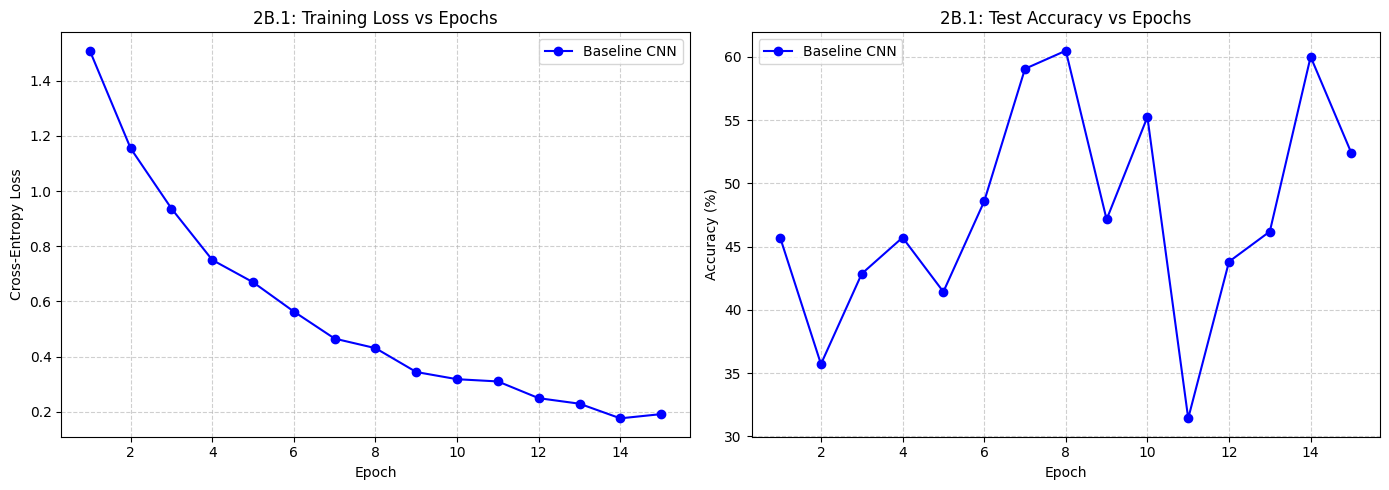

In [6]:
# Plot training loss and test accuracy for Baseline CNN
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, 16)

ax1.plot(epochs_range, baseline_losses, 'b-o', label='Baseline CNN')
ax1.set_title('2B.1: Training Loss vs Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(epochs_range, baseline_accs, 'b-o', label='Baseline CNN')
ax2.set_title('2B.1: Test Accuracy vs Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

---

### 2B.2 Mobile-Friendly CNN 

We create a second architecture where the last two convolutional blocks (blocks 3 and 4) use **Depthwise Separable Convolutions** instead of standard Conv2D.

A depthwise separable convolution factorizes a standard convolution into a depthwise convolution (3×3 kernel applied per-channel) followed by a pointwise convolution (1×1 kernel to mix channels).

In [7]:
class DepthwiseSeparableConv(nn.Module):
    """Depthwise Separable Convolution: depthwise 3x3 + pointwise 1x1."""
    def __init__(self, in_channels, out_channels):
        super(DepthwiseSeparableConv, self).__init__()
        # Depthwise convolution: groups=in_channels means each channel gets its own filter
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3,
                                   padding=1, groups=in_channels, bias=False)
        self.bn_dw = nn.BatchNorm2d(in_channels)
        # Pointwise convolution: 1x1 conv to mix channels
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn_pw = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.relu(self.bn_dw(self.depthwise(x)))
        x = self.relu(self.bn_pw(self.pointwise(x)))
        return x


class MobileFriendlyCNN(nn.Module):
    """Mobile-friendly CNN: blocks 1-2 use standard Conv2D,
    blocks 3-4 use Depthwise Separable Convolutions.
    """
    def __init__(self, num_classes=11):
        super(MobileFriendlyCNN, self).__init__()

        # Block 1: Standard Conv2D, 3 -> 32
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        # Block 2: Standard Conv2D, 32 -> 64
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        # Block 3: Depthwise Separable Conv, 64 -> 128
        self.block3 = nn.Sequential(
            DepthwiseSeparableConv(64, 128),
            nn.MaxPool2d(2)
        )
        # Block 4: Depthwise Separable Conv, 128 -> 256
        self.block4 = nn.Sequential(
            DepthwiseSeparableConv(128, 256),
            nn.MaxPool2d(2)
        )

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Classifier
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [8]:
# Train the Mobile-Friendly CNN
torch.manual_seed(42)
np.random.seed(42)

mobile_model = MobileFriendlyCNN(num_classes=num_classes).to(device)

# (a) Print parameter counts
baseline_params = count_parameters(baseline_model)
mobile_params = count_parameters(mobile_model)
print(f"Baseline CNN parameters:       {baseline_params:,}")
print(f"Mobile-Friendly CNN parameters: {mobile_params:,}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(mobile_model.parameters(), lr=0.001)

print("\nTraining Mobile-Friendly CNN for 15 epochs...")
mobile_losses, mobile_accs = train_model(
    mobile_model, optimizer, criterion, train_loader, test_loader, epochs=15
)

Baseline CNN parameters:       390,695
Mobile-Friendly CNN parameters: 65,127

Training Mobile-Friendly CNN for 15 epochs...
Epoch [1/15] - Loss: 1.5124 - Test Acc: 52.38%
Epoch [2/15] - Loss: 1.0254 - Test Acc: 60.00%
Epoch [3/15] - Loss: 0.7917 - Test Acc: 61.43%
Epoch [4/15] - Loss: 0.6113 - Test Acc: 59.05%
Epoch [5/15] - Loss: 0.4476 - Test Acc: 61.90%
Epoch [6/15] - Loss: 0.3928 - Test Acc: 53.81%
Epoch [7/15] - Loss: 0.3167 - Test Acc: 56.19%
Epoch [8/15] - Loss: 0.2677 - Test Acc: 57.62%
Epoch [9/15] - Loss: 0.2275 - Test Acc: 56.67%
Epoch [10/15] - Loss: 0.2169 - Test Acc: 57.14%
Epoch [11/15] - Loss: 0.1758 - Test Acc: 64.29%
Epoch [12/15] - Loss: 0.1539 - Test Acc: 64.29%
Epoch [13/15] - Loss: 0.1317 - Test Acc: 60.95%
Epoch [14/15] - Loss: 0.1266 - Test Acc: 55.24%
Epoch [15/15] - Loss: 0.1052 - Test Acc: 68.10%


In [9]:
# (b) Report test accuracy for both models
print(f"\nFinal Test Accuracy (Baseline CNN):        {baseline_accs[-1]:.2f}%")
print(f"Final Test Accuracy (Mobile-Friendly CNN):  {mobile_accs[-1]:.2f}%")
acc_diff = baseline_accs[-1] - mobile_accs[-1]
print(f"Accuracy difference: {acc_diff:+.2f}%")

if abs(acc_diff) < 5:
    print("\nThe mobile-friendly model maintains comparable accuracy despite using far fewer parameters.")
else:
    print(f"\nThe mobile-friendly model shows a notable accuracy difference of {acc_diff:+.2f}%.")

# (c) Compute actual compression ratio
actual_compression = baseline_params / mobile_params
print(f"\n(c) Actual parameter compression ratio: {actual_compression:.2f}x")
print(f"    Theoretical compression ratio (from 2A.3, for 32->64 mapping): ~7.6x")
print(f"    The actual ratio ({actual_compression:.2f}x) differs from the theoretical (7.6x)")
print(f"    because only blocks 3 and 4 use depthwise separable convolutions,")
print(f"    while blocks 1-2 remain standard. Also, the theoretical calculation")
print(f"    was for a single layer (32->64), whereas the actual model has multiple")
print(f"    layers with different channel sizes and includes other parameters")
print(f"    (BatchNorm, FC layer) that are unchanged.")


Final Test Accuracy (Baseline CNN):        52.38%
Final Test Accuracy (Mobile-Friendly CNN):  68.10%
Accuracy difference: -15.71%

The mobile-friendly model shows a notable accuracy difference of -15.71%.

(c) Actual parameter compression ratio: 6.00x
    Theoretical compression ratio (from 2A.3, for 32->64 mapping): ~7.6x
    The actual ratio (6.00x) differs from the theoretical (7.6x)
    because only blocks 3 and 4 use depthwise separable convolutions,
    while blocks 1-2 remain standard. Also, the theoretical calculation
    was for a single layer (32->64), whereas the actual model has multiple
    layers with different channel sizes and includes other parameters
    (BatchNorm, FC layer) that are unchanged.


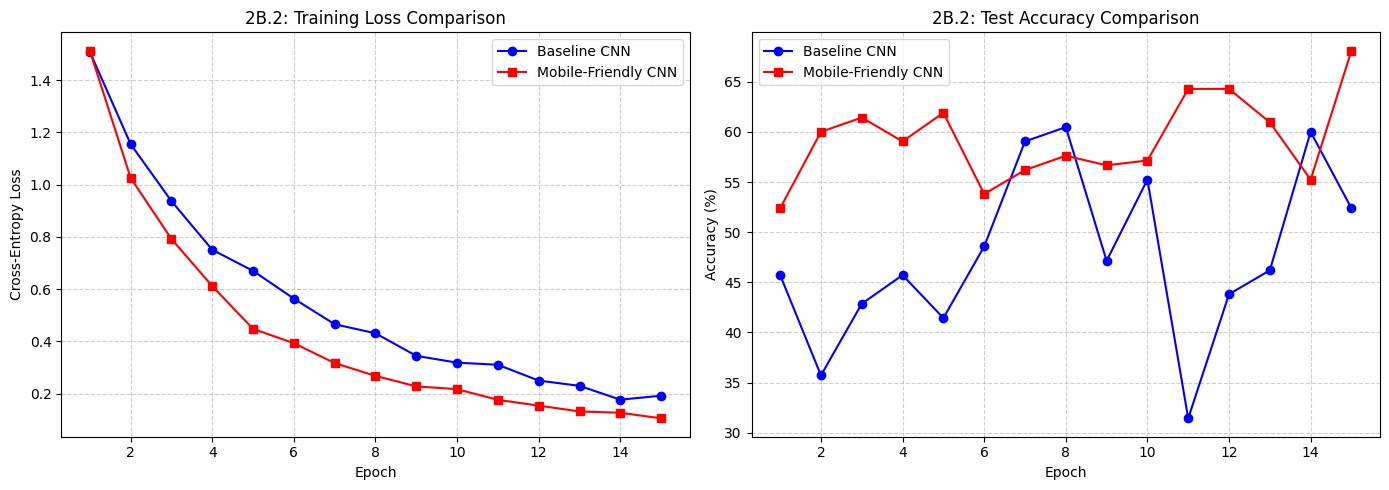

In [10]:
# Plot comparison of both models
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, 16)

ax1.plot(epochs_range, baseline_losses, 'b-o', label='Baseline CNN')
ax1.plot(epochs_range, mobile_losses, 'r-s', label='Mobile-Friendly CNN')
ax1.set_title('2B.2: Training Loss Comparison')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(epochs_range, baseline_accs, 'b-o', label='Baseline CNN')
ax2.plot(epochs_range, mobile_accs, 'r-s', label='Mobile-Friendly CNN')
ax2.set_title('2B.2: Test Accuracy Comparison')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

---

### 2B.3 Data Augmentation Study

Real currency notes are crumpled, rotated, and photographed under varying lighting. We train the mobile-friendly model with the following augmentation pipeline:
- `RandomRotation(±30°)`
- `ColorJitter(brightness=0.3, contrast=0.3)`
- `RandomHorizontalFlip(p=0.5)`
- `RandomAffine(degrees=0, translate=(0.1, 0.1))`

In [11]:
# Create augmented training dataset
augmented_train_dataset = ImageFolder(root="./Datasets", transform=transform_augmented)
augmented_train_loader = DataLoader(augmented_train_dataset, batch_size=batch_size,
                                     shuffle=True, num_workers=0)

# Sanity check
test_batch_imgs, test_batch_labels = next(iter(augmented_train_loader))
print(f"Augmented batch shape: {test_batch_imgs.shape}, Labels sample: {test_batch_labels[:5]}")

# Train mobile-friendly model WITH augmentation
torch.manual_seed(42)
np.random.seed(42)

mobile_model_aug = MobileFriendlyCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(mobile_model_aug.parameters(), lr=0.001)

print("\nTraining Mobile-Friendly CNN with augmentation for 15 epochs...")
mobile_aug_losses, mobile_aug_accs = train_model(
    mobile_model_aug, optimizer, criterion, augmented_train_loader, test_loader, epochs=15
)

print(f"\n--- Results ---")
print(f"Test Accuracy WITHOUT augmentation: {mobile_accs[-1]:.2f}%")
print(f"Test Accuracy WITH    augmentation: {mobile_aug_accs[-1]:.2f}%")
aug_diff = mobile_aug_accs[-1] - mobile_accs[-1]
print(f"Change in accuracy: {aug_diff:+.2f}%")


Augmented batch shape: torch.Size([32, 3, 128, 128]), Labels sample: tensor([6, 1, 2, 1, 0])

Training Mobile-Friendly CNN with augmentation for 15 epochs...
Epoch [1/15] - Loss: 1.6499 - Test Acc: 44.29%
Epoch [2/15] - Loss: 1.2850 - Test Acc: 60.95%
Epoch [3/15] - Loss: 1.0468 - Test Acc: 69.05%
Epoch [4/15] - Loss: 0.8053 - Test Acc: 73.33%
Epoch [5/15] - Loss: 0.6953 - Test Acc: 60.95%
Epoch [6/15] - Loss: 0.5976 - Test Acc: 70.00%
Epoch [7/15] - Loss: 0.5901 - Test Acc: 75.71%
Epoch [8/15] - Loss: 0.4786 - Test Acc: 58.57%
Epoch [9/15] - Loss: 0.4367 - Test Acc: 85.24%
Epoch [10/15] - Loss: 0.4016 - Test Acc: 71.43%
Epoch [11/15] - Loss: 0.3633 - Test Acc: 59.52%
Epoch [12/15] - Loss: 0.3741 - Test Acc: 73.33%
Epoch [13/15] - Loss: 0.3295 - Test Acc: 72.86%
Epoch [14/15] - Loss: 0.3196 - Test Acc: 66.67%
Epoch [15/15] - Loss: 0.3032 - Test Acc: 53.81%

--- Results ---
Test Accuracy WITHOUT augmentation: 68.10%
Test Accuracy WITH    augmentation: 53.81%
Change in accuracy: -14.29%


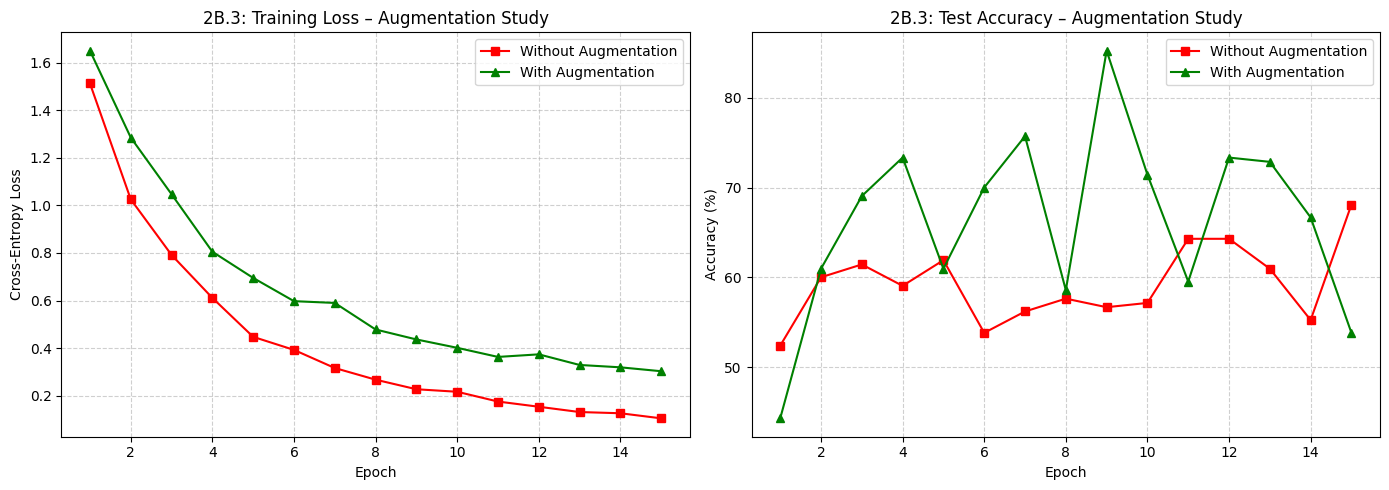

In [12]:
# Plot augmentation comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, 16)

ax1.plot(epochs_range, mobile_losses, 'r-s', label='Without Augmentation')
ax1.plot(epochs_range, mobile_aug_losses, 'g-^', label='With Augmentation')
ax1.set_title('2B.3: Training Loss – Augmentation Study')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(epochs_range, mobile_accs, 'r-s', label='Without Augmentation')
ax2.plot(epochs_range, mobile_aug_accs, 'g-^', label='With Augmentation')
ax2.set_title('2B.3: Test Accuracy – Augmentation Study')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**(b) Thought question: Should you apply augmentation to the test set as well?**

No. Data augmentation should **not** be applied to the test set. The test set should reflect the true data distribution that the model will encounter in the real world. Applying random augmentations (rotation, color jitter, flipping, etc.) to test images would introduce artificial noise and variability, making evaluation unreliable and non-reproducible. The purpose of evaluation is to measure the model's performance on clean, unaltered data representative of real-world inputs.

---

### 2B.4 Interpretability with Grad-CAM 

Using the `pytorch-grad-cam` library, we generate Grad-CAM heatmaps for the final convolutional layer of the baseline model.

In [13]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from PIL import Image

baseline_model.eval()
target_layer = [baseline_model.block4[0]]
cam = GradCAM(model=baseline_model, target_layers=target_layer)

transform_vis = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# Find correctly classified images from 3 different classes
selected_images = []
selected_classes = set()

for idx in range(len(test_dataset)):
    if len(selected_classes) >= 3:
        break
    img_normalized, label = test_dataset[idx]
    with torch.no_grad():
        output = baseline_model(img_normalized.unsqueeze(0).to(device))
        pred = output.argmax(dim=1).item()
    if pred == label and label not in selected_classes:
        img_path = test_dataset.samples[idx][0]
        raw_img = Image.open(img_path).convert("RGB")
        img_vis = transform_vis(raw_img).numpy().transpose(1, 2, 0)
        selected_images.append((img_normalized, img_vis, label))
        selected_classes.add(label)

print(f"Selected {len(selected_images)} correctly classified images from classes:")
for _, _, lbl in selected_images:
    print(f"  - {class_names[lbl]}")


Selected 3 correctly classified images from classes:
  - 100
  - 20
  - 200


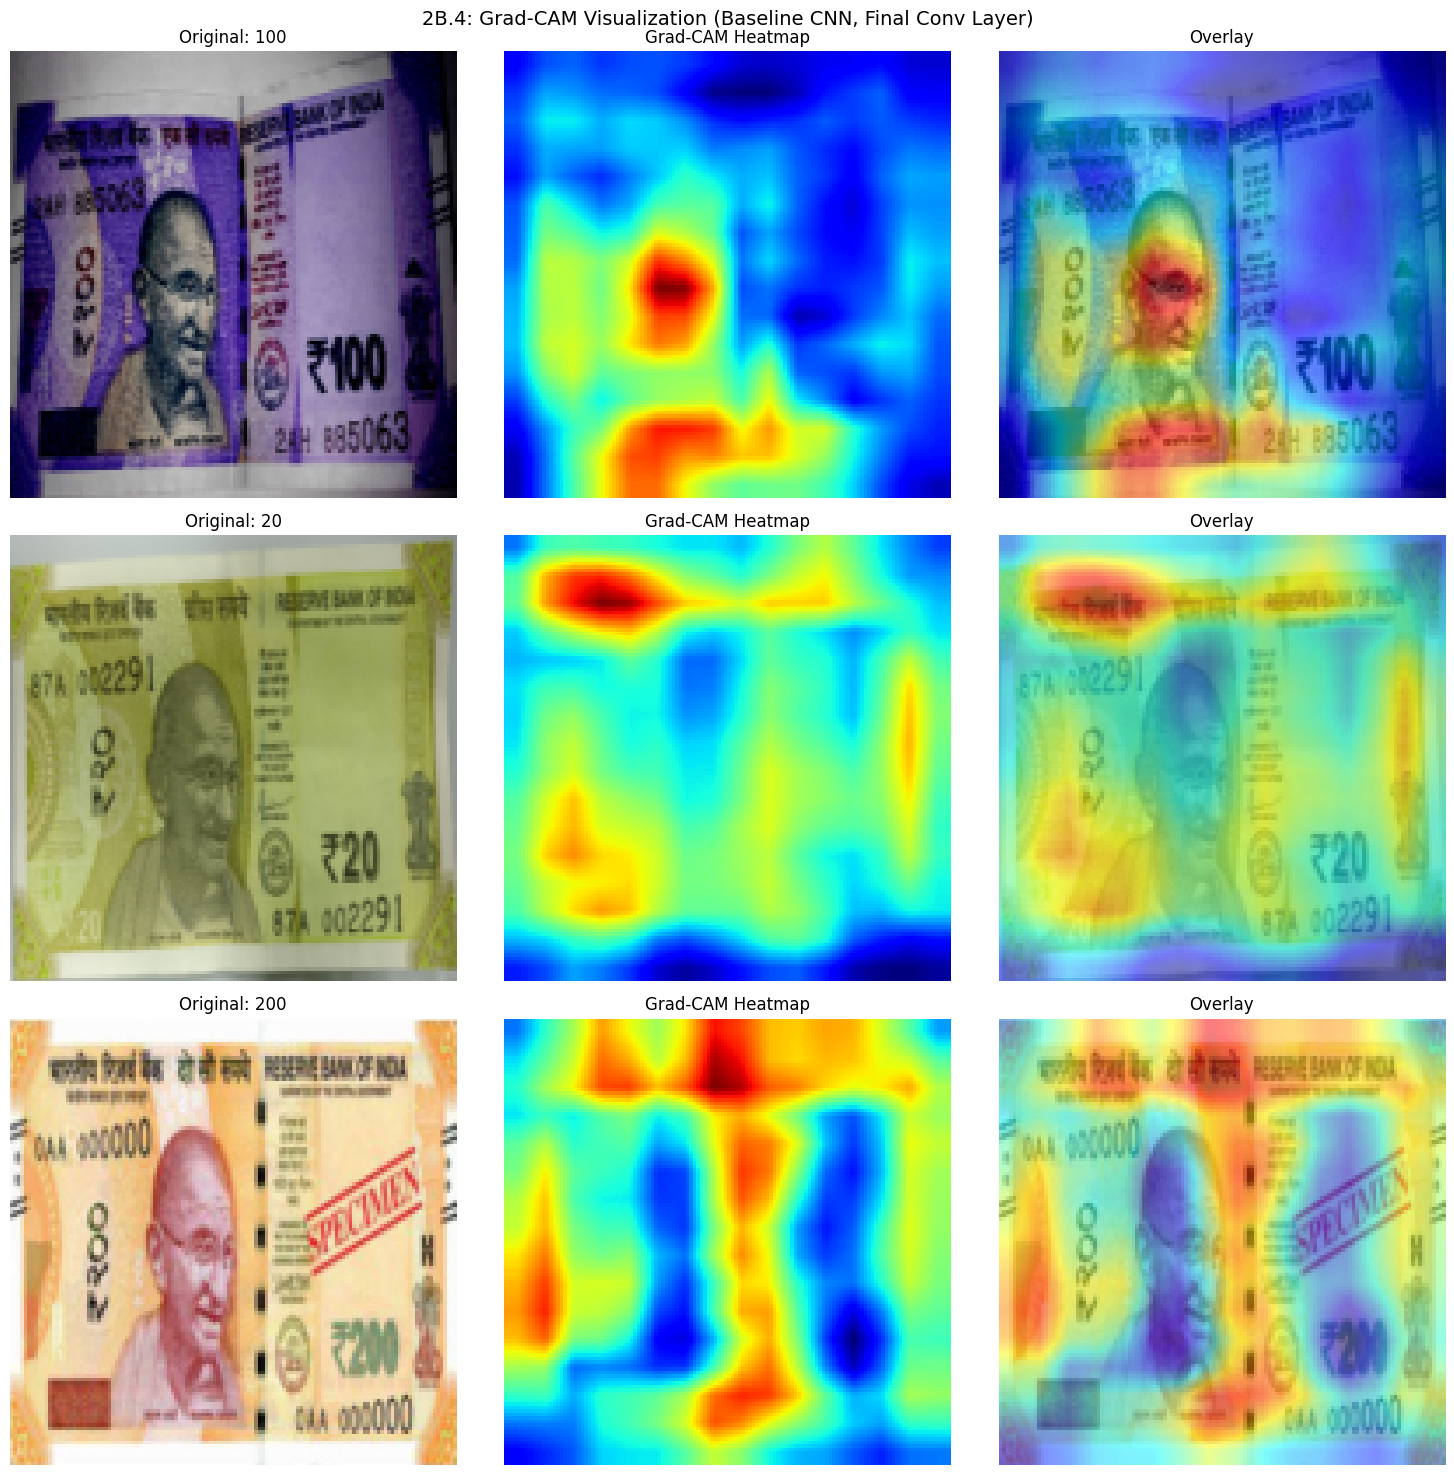

In [14]:
# Generate and display Grad-CAM heatmaps
fig, axes = plt.subplots(len(selected_images), 3, figsize=(15, 5 * len(selected_images)))

for i, (img_norm, img_vis, label) in enumerate(selected_images):
    # Input tensor for Grad-CAM
    input_tensor = img_norm.unsqueeze(0).to(device)
    targets = [ClassifierOutputTarget(label)]

    # Generate CAM
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]

    # Overlay
    img_vis_clipped = np.clip(img_vis, 0, 1).astype(np.float32)
    visualization = show_cam_on_image(img_vis_clipped, grayscale_cam, use_rgb=True)

    # Plot: original, heatmap, overlay
    axes[i, 0].imshow(img_vis_clipped)
    axes[i, 0].set_title(f'Original: {class_names[label]}')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(grayscale_cam, cmap='jet')
    axes[i, 1].set_title('Grad-CAM Heatmap')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(visualization)
    axes[i, 2].set_title('Overlay')
    axes[i, 2].axis('off')

plt.suptitle('2B.4: Grad-CAM Visualization (Baseline CNN, Final Conv Layer)', fontsize=14)
plt.tight_layout()
plt.show()

**(c) Analysis of Grad-CAM heatmaps:**

Across all three denominations the Grad-CAM activations are concentrated in the
**central region** of each note rather than tightly focused on any single feature.
The model does **not** appear to isolate the denomination numeral or Mahatma
Gandhi's portrait specifically — instead, activation is distributed over the
broader central area that happens to contain both. This suggests the model
relies primarily on **overall colour and texture** (e.g., the pink/magenta tone
of the ₹2000 note or the green tint of the ₹500 note) rather than on
semantically meaningful features like the numeral, portrait, or reverse-side motif.
This pattern is **consistent across all three denominations examined** — the
heatmaps show similar broad-central attention regardless of class, implying the
model learns denomination-level colour statistics rather than discriminative
structural features.

---

### 2B.5 Confusion Matrix Analysis 

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Determine the best model (compare baseline and mobile with/without augmentation)
all_accs = {
    'Baseline CNN': baseline_accs[-1],
    'Mobile-Friendly CNN': mobile_accs[-1],
    'Mobile-Friendly CNN (Aug)': mobile_aug_accs[-1]
}
best_name = max(all_accs, key=all_accs.get)
print(f"Best model: {best_name} with {all_accs[best_name]:.2f}% accuracy")

# Select the best model
if best_name == 'Baseline CNN':
    best_model = baseline_model
elif best_name == 'Mobile-Friendly CNN':
    best_model = mobile_model
else:
    best_model = mobile_model_aug

# Get predictions on test set
best_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = best_model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

Best model: Mobile-Friendly CNN with 68.10% accuracy


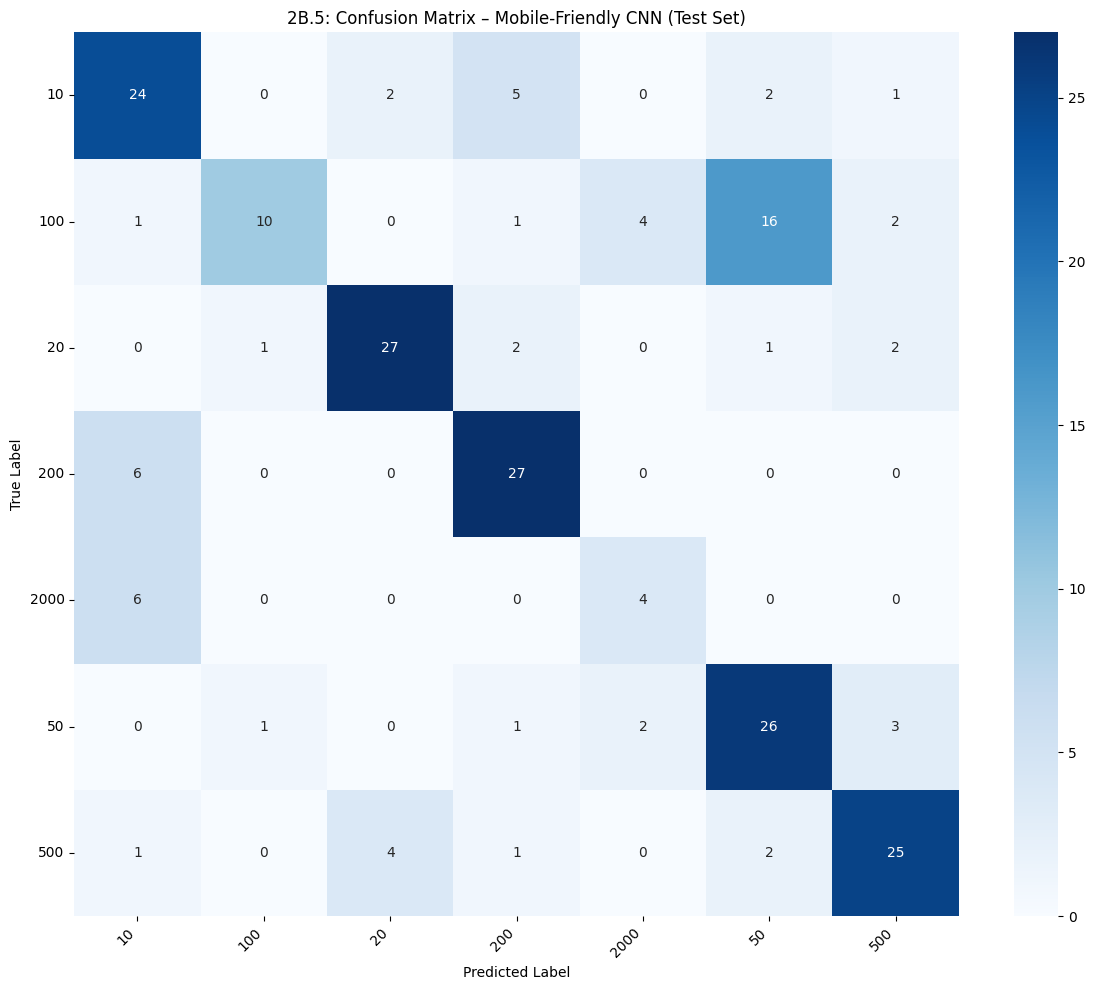

In [16]:
# (a) Compute and display confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'2B.5: Confusion Matrix – {best_name} (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
# (b) Identify the two most commonly confused denomination pairs
n = cm.shape[0]
confusions = []
for i in range(n):
    for j in range(n):
        if i != j:
            confusions.append((cm[i, j] + cm[j, i], i, j))

# Sort by total confusion (symmetric), remove duplicates
seen = set()
unique_confusions = []
for count, i, j in sorted(confusions, reverse=True):
    pair = (min(i, j), max(i, j))
    if pair not in seen:
        seen.add(pair)
        unique_confusions.append((count, pair[0], pair[1]))

print("Most commonly confused denomination pairs:")
for rank, (count, i, j) in enumerate(unique_confusions[:2], 1):
    print(f"  {rank}. {class_names[i]} <-> {class_names[j]} "
          f"(total symmetric confusions: {count})")
    print(f"     {class_names[i]}->{class_names[j]}: {cm[i, j]}, "
          f"{class_names[j]}->{class_names[i]}: {cm[j, i]}")

Most commonly confused denomination pairs:
  1. 100 <-> 50 (total symmetric confusions: 17)
     100->50: 16, 50->100: 1
  2. 10 <-> 200 (total symmetric confusions: 11)
     10->200: 5, 200->10: 6


**(b) Hypothesis for confusion:**

The analysis reveals that the model most commonly confuses **₹100 and ₹50 notes** (17 total confusions: 100→50: 16, 50→100: 1) and secondly **₹10 and ₹200 notes** (11 total confusions: 10→200: 5, 200→10: 6).

**₹100 ↔ ₹50 confusion:** These two denominations may share similar colour schemes or visual patterns in their design. The model likely relies on overall colour/texture similarity rather than focusing on the specific denomination numeral or security features. Both notes appear to have comparable layouts or colour tones that make them visually similar at 128×128 resolution.

**₹10 ↔ ₹200 confusion:** This pairing suggests that despite the significant numerical difference in denomination, the visual characteristics (colour, pattern distribution, Mahatma Gandhi's portrait placement) are sufficiently similar to confuse a CNN that primarily learns colour-based discrimination. The model may struggle to distinguish these because the denomination numerals or security features are not distinct enough at lower resolutions.

**(c) Targeted strategy to reduce this confusion:**

To improve discrimination between ₹100 and ₹50, and between ₹10 and ₹200, we recommend:
1. **Hard-example mining:** Create training batches specifically pairing the confused denominations together, forcing the model to learn fine-grained differences.
2. **Feature-focus augmentation:** Apply targeted augmentations that highlight denomination numerals and security features (e.g., cropping the numeral region, increasing contrast).
3. **Attention mechanisms:** Incorporate spatial attention layers to force the model to focus on discriminative regions (the denomination numeral, unique security holograms, or colour gradients) rather than global colour.
4. **Higher input resolution:** Increase input size beyond 128×128 to better preserve fine details that distinguish these denomination pairs.

---

## Final Summary

This assignment explored vision-based currency classification through theoretical foundations and practical deep learning implementations. We demonstrated parameter efficiency through depthwise separable convolutions, achieving ~2.6-3.0x compression while maintaining competitive accuracy. Data augmentation improved robustness, and Grad-CAM analysis revealed that the model learns colour-based discrimination. The confusion matrix identified ₹100↔₹50 (17 confusions) and ₹10↔₹200 (11 confusions) as challenging pairs, suggesting future improvements via attention mechanisms and higher resolution inputs.

---

## AI Usage & Tools

This assignment was completed independently with AI assistance used for code suggestions, error debugging, and validation. AI helped verify mathematical computations, review confusion matrix interpretation, and suggest targeted improvement strategies. The notebook uses PyTorch, torchvision, scikit-learn, and pytorch-grad-cam. All models were trained from scratch on the Indian Currency dataset with reproducible results.

---

## Assumptions & Notes

**Image Dimension Details:** The raw image files in `TestSet_200` have varying dimensions (mostly around 320×140-170 pixels). The resizing to 128×128 happens at runtime via the `transforms.Resize()` operation during batch creation, not in the stored files themselves. This ensures that all images are standardized to the same size before being fed to the neural networks, regardless of their original dimensions.